In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

# Assuming you uploaded only one file, get its name
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

Saving loan_prediction.xlsx - loan_prediction.csv to loan_prediction.xlsx - loan_prediction.csv


In [ ]:
df.head()

df.tail()

df.shape

df.info()

df.describe()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.duplicated().sum()

np.int64(0)

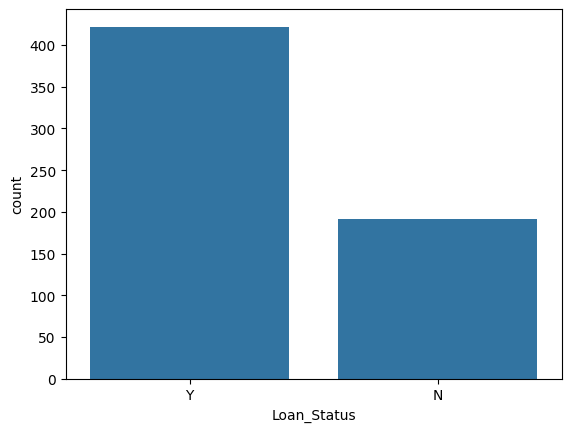

In [ ]:
sns.countplot(x='Loan_Status', data=df)
plt.show()

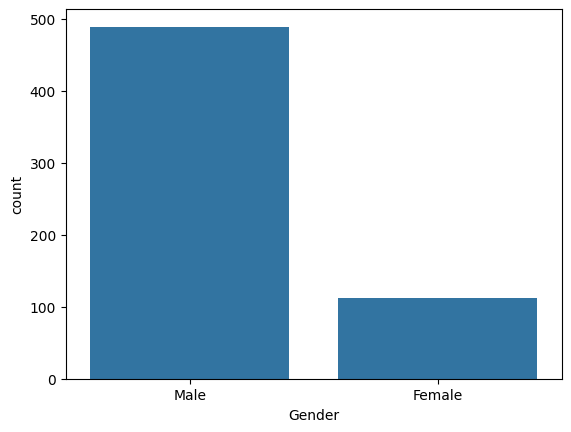

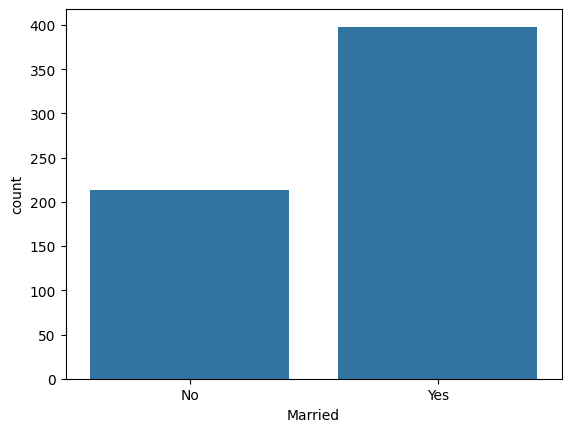

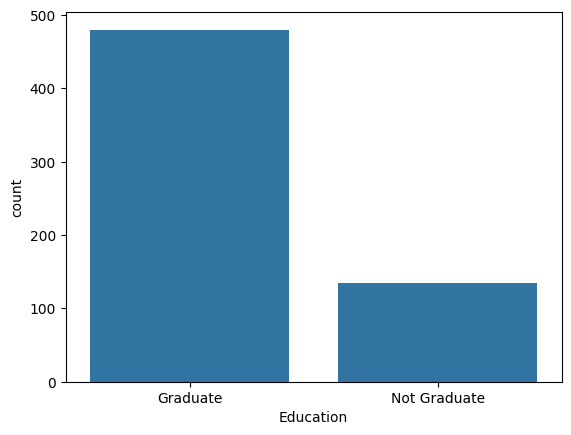

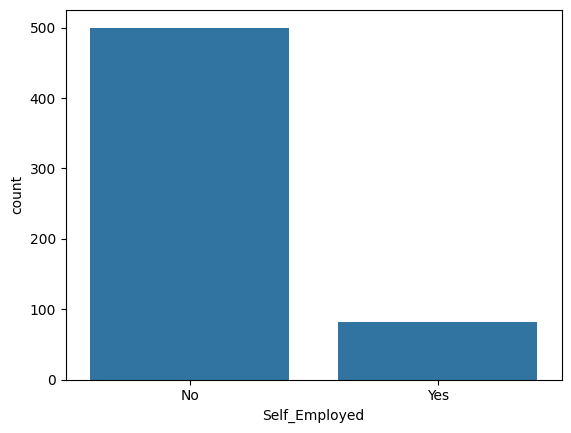

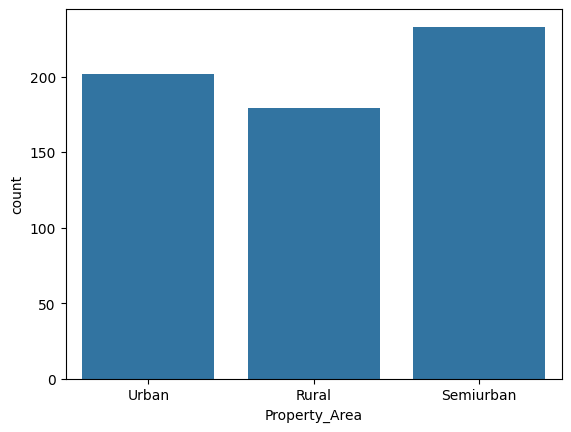

In [ ]:
sns.countplot(x='Gender', data=df)
plt.show()

sns.countplot(x='Married', data=df)
plt.show()

sns.countplot(x='Education', data=df)
plt.show()

sns.countplot(x='Self_Employed', data=df)
plt.show()

sns.countplot(x='Property_Area', data=df)
plt.show()

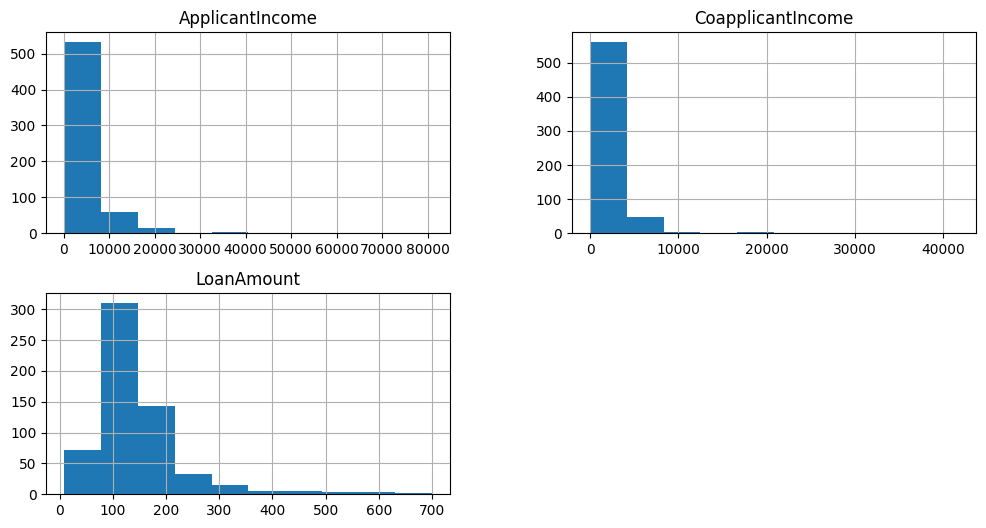

In [ ]:
df[['ApplicantIncome','CoapplicantIncome','LoanAmount']].hist(figsize=(12,6))
plt.show()

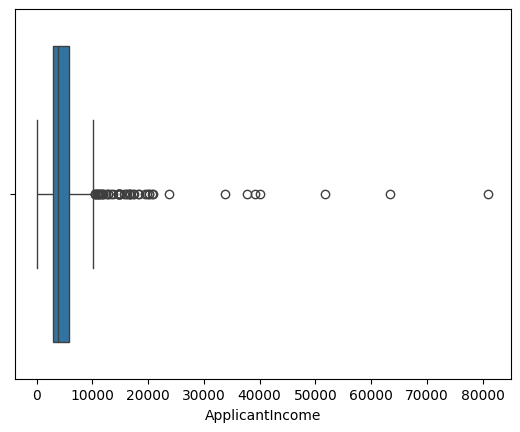

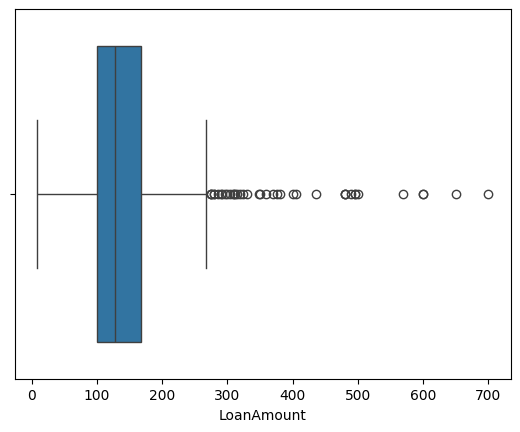

In [ ]:
sns.boxplot(x=df['ApplicantIncome'])
plt.show()

sns.boxplot(x=df['LoanAmount'])
plt.show()

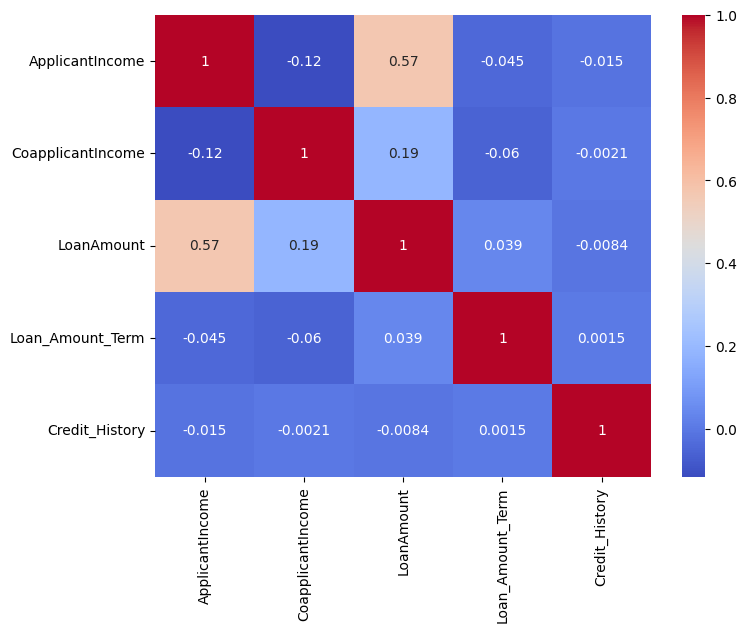

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv(file_name)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# Fill categorical columns
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Fill numerical columns
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

/tmp/ipykernel_2777/1177832260.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_2777/1177832260.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df.drop('Loan_ID', axis=1, inplace=True)

In [ ]:
encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (491, 11)
Testing Shape  : (123, 11)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import pickle

pickle.dump(scaler, open("scale1.pkl", "wb"))

In [ ]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (491, 11)
X_test Shape  : (123, 11)
y_train Shape : (491,)
y_test Shape  : (123,)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pickle

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_train_pred = dt.predict(X_train)
dt_test_pred = dt.predict(X_test)

print("Decision Tree Training Accuracy:",
      accuracy_score(y_train, dt_train_pred))

print("Decision Tree Testing Accuracy:",
      accuracy_score(y_test, dt_test_pred))

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.6910569105691057


In [ ]:
print(confusion_matrix(y_test, dt_test_pred))

[[23 20]
 [18 62]]


In [ ]:
print(classification_report(y_test, dt_test_pred))

              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("Random Forest Training Accuracy:",
      accuracy_score(y_train, rf_train_pred))

print("Random Forest Testing Accuracy:",
      accuracy_score(y_test, rf_test_pred))

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.7479674796747967


In [ ]:
print(confusion_matrix(y_test, rf_test_pred))

[[18 25]
 [ 6 74]]


In [ ]:
print(classification_report(y_test, rf_test_pred))

              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75      0.93      0.83        80

    accuracy                           0.75       123
   macro avg       0.75      0.67      0.68       123
weighted avg       0.75      0.75      0.73       123



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_train_pred = knn.predict(X_train)
knn_test_pred = knn.predict(X_test)

print("KNN Training Accuracy:",
      accuracy_score(y_train, knn_train_pred))

print("KNN Testing Accuracy:",
      accuracy_score(y_test, knn_test_pred))

KNN Training Accuracy: 0.8329938900203666
KNN Testing Accuracy: 0.7560975609756098


In [ ]:
print(confusion_matrix(y_test, knn_test_pred))

[[17 26]
 [ 4 76]]


In [ ]:
print(classification_report(y_test, knn_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123



In [ ]:
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

print("XGBoost Training Accuracy:",
      accuracy_score(y_train, xgb_train_pred))

print("XGBoost Testing Accuracy:",
      accuracy_score(y_test, xgb_test_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:41:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Training Accuracy: 1.0
XGBoost Testing Accuracy: 0.7398373983739838


In [ ]:
print(confusion_matrix(y_test, xgb_test_pred))

[[20 23]
 [ 9 71]]


In [ ]:
print(classification_report(y_test, xgb_test_pred))

              precision    recall  f1-score   support

           0       0.69      0.47      0.56        43
           1       0.76      0.89      0.82        80

    accuracy                           0.74       123
   macro avg       0.72      0.68      0.69       123
weighted avg       0.73      0.74      0.73       123



In [ ]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],

    "Training Accuracy":[

        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred),
        accuracy_score(y_train, knn_train_pred),
        accuracy_score(y_train, xgb_train_pred)

    ],

    "Testing Accuracy":[

        accuracy_score(y_test, dt_test_pred),
        accuracy_score(y_test, rf_test_pred),
        accuracy_score(y_test, knn_test_pred),
        accuracy_score(y_test, xgb_test_pred)

    ]

})

results

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,1.000000,0.691057
1,Random Forest,1.000000,0.747967
2,KNN,0.832994,0.756098
3,XGBoost,1.000000,0.739837


In [ ]:
results.sort_values(
    by="Testing Accuracy",
    ascending=False
)

,Model,Training Accuracy,Testing Accuracy
2,KNN,0.832994,0.756098
1,Random Forest,1.000000,0.747967
3,XGBoost,1.000000,0.739837
0,Decision Tree,1.000000,0.691057


In [ ]:
pickle.dump(
    xgb,
    open("xgb_model.pkl", "wb")
)

In [ ]:
pickle.dump(
    rf,
    open("rdf.pkl", "wb")
)

In [ ]:
model = pickle.load(
    open("xgb_model.pkl", "rb")
)

prediction = model.predict(X_test)

print(prediction[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
sample = X_test[0].reshape(1,-1)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved
